In [1]:
import sys
import pandas as pd

print("Python:", sys.executable)
print("Pandas:", pd.__version__)
print("Week 1 environment is ready!")

Python: d:\Certifications\Project\Junior-Data-Science-Internship\.venv\Scripts\python.exe
Pandas: 3.0.6
Week 1 environment is ready!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
file_path = "../data/raw/Online Retail.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 541909
Columns: 8


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [7]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

In [8]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [9]:
df.describe(include="object")

C:\Users\Anand\AppData\Local\Temp\ipykernel_24696\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,InvoiceNo,StockCode,Description,Country
count,541909,541909,540455,541909
unique,25900,4070,4223,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,1114,2313,2369,495478


In [10]:
print("Unique Invoice Numbers:", df["InvoiceNo"].nunique())
print("Unique Stock Codes:", df["StockCode"].nunique())
print("Unique Countries:", df["Country"].nunique())
print("Unique Customers:", df["CustomerID"].nunique())

Unique Invoice Numbers: 25900
Unique Stock Codes: 4070
Unique Countries: 38
Unique Customers: 4372


In [11]:
missing_count = df.isnull().sum()

missing_count

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [12]:
missing_count = df.isnull().sum()

missing_count

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [13]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage

InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
dtype: float64

In [14]:
missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_summary = missing_summary.sort_values(
    by="Missing Values",
    ascending=False
)

missing_summary

,Missing Values,Missing Percentage
CustomerID,135080,24.926694
Description,1454,0.268311
StockCode,0,0.000000
InvoiceNo,0,0.000000
Quantity,0,0.000000
InvoiceDate,0,0.000000
UnitPrice,0,0.000000
Country,0,0.000000


In [15]:
missing_summary[missing_summary["Missing Values"] > 0]

,Missing Values,Missing Percentage
CustomerID,135080,24.926694
Description,1454,0.268311


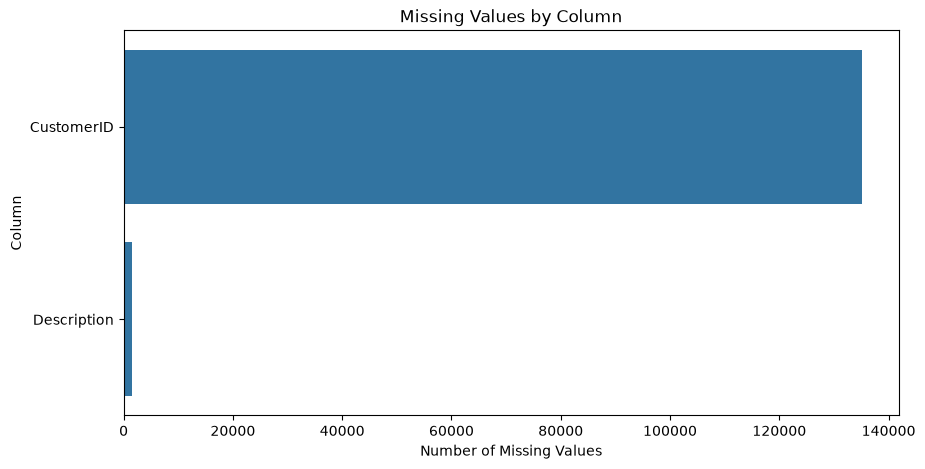

In [16]:
missing_data = missing_summary[
    missing_summary["Missing Values"] > 0
]

plt.figure(figsize=(10, 5))

sns.barplot(
    x=missing_data["Missing Values"],
    y=missing_data.index
)

plt.title("Missing Values by Column")
plt.xlabel("Number of Missing Values")
plt.ylabel("Column")

plt.show()

## Missing Value Analysis

Missing values were identified using Pandas `isnull()` functions. Both the total number and percentage of missing values were calculated for each column.

The analysis showed that missing values were primarily present in the `Description` and `CustomerID` columns. These missing values were not immediately removed because their treatment depends on the analytical purpose and business context of the dataset.

Further investigation will be performed before deciding whether to remove, retain, or otherwise handle these records.

In [17]:
duplicate_count = df.duplicated().sum()

print("Total duplicate rows:", duplicate_count)

Total duplicate rows: 5268


In [18]:
duplicates = df[df.duplicated(keep=False)]

duplicates.head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
548,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom


In [19]:
print("Duplicate records including their copies:", len(duplicates))

Duplicate records including their copies: 10147


In [20]:
duplicate_percentage = (duplicate_count / len(df)) * 100

print(f"Duplicate percentage: {duplicate_percentage:.2f}%")

Duplicate percentage: 0.97%


In [21]:
df.duplicated().value_counts()

False    536641
True       5268
Name: count, dtype: int64

## Duplicate Records Analysis

Duplicate records were identified using Pandas' `duplicated()` function.

The analysis identified multiple completely duplicated rows in the dataset. These records contain the same values across all available columns.

Since exact duplicate rows do not provide additional information and may lead to double counting during future analysis, they will be considered for removal during the data cleaning stage.

The duplicate percentage was also calculated to understand the extent of duplication relative to the complete dataset.

In [22]:
negative_quantity = (df["Quantity"] < 0).sum()

print("Negative Quantity records:", negative_quantity)

Negative Quantity records: 10624


In [23]:
zero_quantity = (df["Quantity"] == 0).sum()

print("Zero Quantity records:", zero_quantity)

Zero Quantity records: 0


In [24]:
negative_price = (df["UnitPrice"] < 0).sum()

print("Negative UnitPrice records:", negative_price)

Negative UnitPrice records: 2


In [25]:
zero_price = (df["UnitPrice"] == 0).sum()

print("Zero UnitPrice records:", zero_price)

Zero UnitPrice records: 2515


In [26]:
negative_quantity_records = df[df["Quantity"] < 0]

negative_quantity_records.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom


In [27]:
negative_quantity_records["InvoiceNo"].astype(str).head(20)

141     C536379
154     C536383
235     C536391
236     C536391
237     C536391
238     C536391
239     C536391
240     C536391
241     C536391
939     C536506
1441    C536543
1442    C536543
1973    C536548
1974    C536548
1975    C536548
1976    C536548
1977    C536548
1978    C536548
1979    C536548
1980    C536548
Name: InvoiceNo, dtype: str

In [28]:
cancelled_invoices = df[
    df["InvoiceNo"].astype(str).str.startswith("C")
]

print("Cancelled invoice records:", len(cancelled_invoices))

Cancelled invoice records: 9288


In [29]:
print(
    "Negative quantity with cancelled invoice:",
    (
        (df["Quantity"] < 0) &
        (df["InvoiceNo"].astype(str).str.startswith("C"))
    ).sum()
)

Negative quantity with cancelled invoice: 9288


In [30]:
print("Minimum Quantity:", df["Quantity"].min())
print("Maximum Quantity:", df["Quantity"].max())

print("Minimum UnitPrice:", df["UnitPrice"].min())
print("Maximum UnitPrice:", df["UnitPrice"].max())

Minimum Quantity: -80995
Maximum Quantity: 80995
Minimum UnitPrice: -11062.06
Maximum UnitPrice: 38970.0


In [31]:
df.nlargest(10, "Quantity")[
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "Country"]
]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,United Kingdom
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,United Kingdom
502122,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,0.00,United Kingdom
74614,542504,37413,NaN,5568,0.00,United Kingdom
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,0.21,United Kingdom
206121,554868,22197,SMALL POPCORN HOLDER,4300,0.72,United Kingdom
220843,556231,85123A,?,4000,0.00,United Kingdom
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,0.82,United Kingdom
270885,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,0.06,United Kingdom
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,United Kingdom


In [32]:
df.nlargest(10, "UnitPrice")[
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "Country"]
]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Country
222681,C556445,M,Manual,-1,38970.00,United Kingdom
524602,C580605,AMAZONFEE,AMAZON FEE,-1,17836.46,United Kingdom
43702,C540117,AMAZONFEE,AMAZON FEE,-1,16888.02,United Kingdom
43703,C540118,AMAZONFEE,AMAZON FEE,-1,16453.71,United Kingdom
15016,C537630,AMAZONFEE,AMAZON FEE,-1,13541.33,United Kingdom
15017,537632,AMAZONFEE,AMAZON FEE,1,13541.33,United Kingdom
16356,C537651,AMAZONFEE,AMAZON FEE,-1,13541.33,United Kingdom
16232,C537644,AMAZONFEE,AMAZON FEE,-1,13474.79,United Kingdom
524601,C580604,AMAZONFEE,AMAZON FEE,-1,11586.50,United Kingdom
299982,A563185,B,Adjust bad debt,1,11062.06,United Kingdom


## Invalid and Abnormal Value Analysis

The `Quantity` and `UnitPrice` columns were examined for negative and zero values.

Negative quantities were investigated rather than automatically classified as errors because, in a retail transaction dataset, negative quantities can represent returned or cancelled items.

The `InvoiceNo` column was also examined for invoice numbers beginning with `C`, which are associated with cancelled transactions in this dataset.

The minimum and maximum values of numerical variables were reviewed to identify potentially abnormal observations. These observations will be considered during the subsequent cleaning and outlier-analysis stages.

In [33]:
df.dtypes


InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

In [34]:
print("InvoiceDate datatype:", df["InvoiceDate"].dtype)

InvoiceDate datatype: datetime64[us]


In [35]:
print(df["InvoiceDate"].head())

0   2010-12-01 08:26:00
1   2010-12-01 08:26:00
2   2010-12-01 08:26:00
3   2010-12-01 08:26:00
4   2010-12-01 08:26:00
Name: InvoiceDate, dtype: datetime64[us]


In [36]:
print("CustomerID datatype:", df["CustomerID"].dtype)
print("Missing CustomerID:", df["CustomerID"].isna().sum())

CustomerID datatype: float64
Missing CustomerID: 135080


In [37]:
print("InvoiceNo datatype:", df["InvoiceNo"].dtype)
print(df["InvoiceNo"].head(10))

InvoiceNo datatype: object
0    536365
1    536365
2    536365
3    536365
4    536365
5    536365
6    536365
7    536366
8    536366
9    536367
Name: InvoiceNo, dtype: object


In [38]:
print(
    "Invoices starting with C:",
    df["InvoiceNo"].astype(str).str.startswith("C").sum()
)

Invoices starting with C: 9288


In [39]:
print("StockCode datatype:", df["StockCode"].dtype)
print(df["StockCode"].head(10))

StockCode datatype: object
0    85123A
1     71053
2    84406B
3    84029G
4    84029E
5     22752
6     21730
7     22633
8     22632
9     84879
Name: StockCode, dtype: object


In [40]:
print("Quantity datatype:", df["Quantity"].dtype)
print("UnitPrice datatype:", df["UnitPrice"].dtype)

Quantity datatype: int64
UnitPrice datatype: float64


In [41]:
print("Minimum Invoice Date:", df["InvoiceDate"].min())
print("Maximum Invoice Date:", df["InvoiceDate"].max())

Minimum Invoice Date: 2010-12-01 08:26:00
Maximum Invoice Date: 2011-12-09 12:50:00


## Data Type and Format Analysis

The data types of all columns were examined using Pandas `dtypes` and related inspection methods.

Special attention was given to the `InvoiceDate`, `CustomerID`, `InvoiceNo`, `StockCode`, `Quantity`, and `UnitPrice` columns.

The `InvoiceDate` column was evaluated to ensure that it is represented using an appropriate datetime format. Numerical columns such as `Quantity` and `UnitPrice` were checked to ensure that they use numeric data types.

Identifier columns such as `InvoiceNo`, `StockCode`, and `CustomerID` were reviewed separately because they represent identifiers rather than continuous numerical measurements.

In [42]:
Q1_quantity = df["Quantity"].quantile(0.25)
Q3_quantity = df["Quantity"].quantile(0.75)

IQR_quantity = Q3_quantity - Q1_quantity

lower_quantity = Q1_quantity - 1.5 * IQR_quantity
upper_quantity = Q3_quantity + 1.5 * IQR_quantity

print("Q1:", Q1_quantity)
print("Q3:", Q3_quantity)
print("IQR:", IQR_quantity)
print("Lower Bound:", lower_quantity)
print("Upper Bound:", upper_quantity)

Q1: 1.0
Q3: 10.0
IQR: 9.0
Lower Bound: -12.5
Upper Bound: 23.5


In [43]:
quantity_outliers = df[
    (df["Quantity"] < lower_quantity) |
    (df["Quantity"] > upper_quantity)
]

print("Quantity outliers:", len(quantity_outliers))

Quantity outliers: 58619


In [44]:
quantity_outlier_percentage = (
    len(quantity_outliers) / len(df)
) * 100

print(f"Quantity outlier percentage: {quantity_outlier_percentage:.2f}%")

Quantity outlier percentage: 10.82%


In [45]:
quantity_outliers[
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "Country"]
].head(20)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Country
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,1.69,United Kingdom
26,536370,22728,ALARM CLOCK BAKELIKE PINK,24,3.75,France
27,536370,22727,ALARM CLOCK BAKELIKE RED,24,3.75,France
30,536370,21883,STARS GIFT TAPE,24,0.65,France
31,536370,10002,INFLATABLE POLITICAL GLOBE,48,0.85,France
32,536370,21791,VINTAGE HEADS AND TAILS CARD GAME,24,1.25,France
34,536370,22326,ROUND SNACK BOXES SET OF4 WOODLAND,24,2.95,France
35,536370,22629,SPACEBOY LUNCH BOX,24,1.95,France
36,536370,22659,LUNCH BOX I LOVE LONDON,24,1.95,France
37,536370,22631,CIRCUS PARADE LUNCH BOX,24,1.95,France


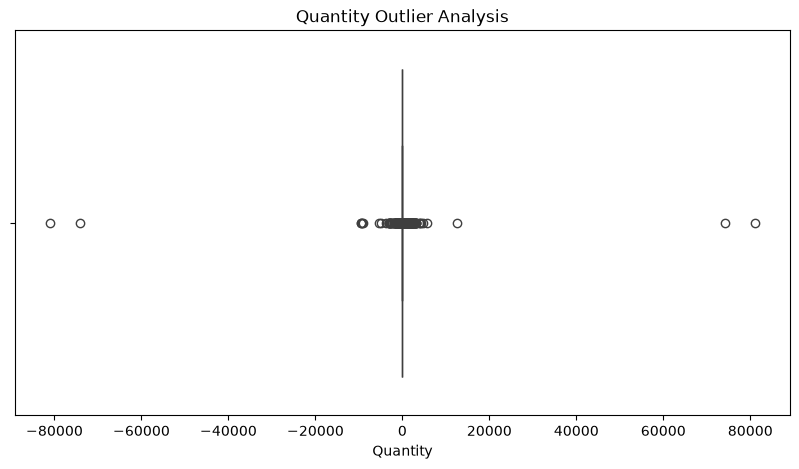

In [46]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df["Quantity"])

plt.title("Quantity Outlier Analysis")
plt.xlabel("Quantity")

plt.show()

In [47]:
Q1_price = df["UnitPrice"].quantile(0.25)
Q3_price = df["UnitPrice"].quantile(0.75)

IQR_price = Q3_price - Q1_price

lower_price = Q1_price - 1.5 * IQR_price
upper_price = Q3_price + 1.5 * IQR_price

print("Q1:", Q1_price)
print("Q3:", Q3_price)
print("IQR:", IQR_price)
print("Lower Bound:", lower_price)
print("Upper Bound:", upper_price)

Q1: 1.25
Q3: 4.13
IQR: 2.88
Lower Bound: -3.0700000000000003
Upper Bound: 8.45


In [48]:
price_outliers = df[
    (df["UnitPrice"] < lower_price) |
    (df["UnitPrice"] > upper_price)
]

print("UnitPrice outliers:", len(price_outliers))

UnitPrice outliers: 39627


In [49]:
price_outlier_percentage = (
    len(price_outliers) / len(df)
) * 100

print(f"UnitPrice outlier percentage: {price_outlier_percentage:.2f}%")

UnitPrice outlier percentage: 7.31%


In [50]:
price_outliers[
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "Country"]
].head(20)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Country
16,536367,22622,BOX OF VINTAGE ALPHABET BLOCKS,2,9.95,United Kingdom
45,536370,POST,POSTAGE,3,18.00,France
65,536374,21258,VICTORIAN SEWING BOX LARGE,32,10.95,United Kingdom
141,C536379,D,Discount,-1,27.50,United Kingdom
151,536382,22839,3 TIER CAKE TIN GREEN AND CREAM,2,14.95,United Kingdom
152,536382,22838,3 TIER CAKE TIN RED AND CREAM,2,14.95,United Kingdom
153,536382,22783,SET 3 WICKER OVAL BASKETS W LIDS,4,16.95,United Kingdom
163,536384,21340,CLASSIC METAL BIRDCAGE PLANT HOLDER,2,12.75,United Kingdom
167,536384,22424,ENAMEL BREAD BIN CREAM,8,10.95,United Kingdom
168,536385,22783,SET 3 WICKER OVAL BASKETS W LIDS,1,19.95,United Kingdom


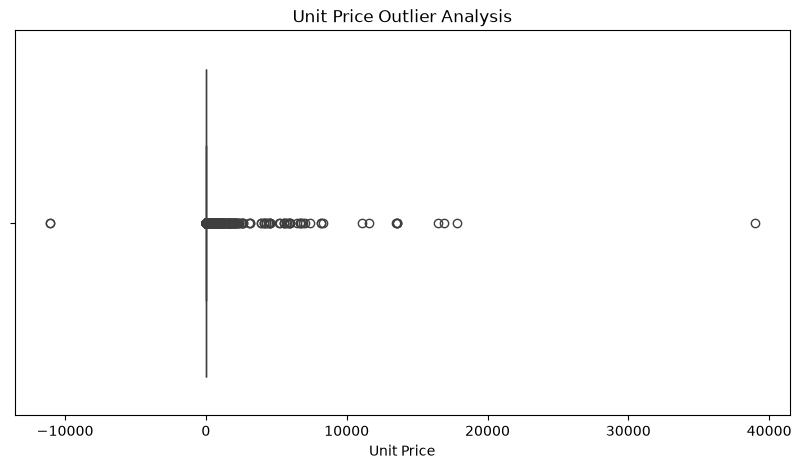

In [51]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df["UnitPrice"])

plt.title("Unit Price Outlier Analysis")
plt.xlabel("Unit Price")

plt.show()

## Outlier Analysis

Outliers were investigated for the `Quantity` and `UnitPrice` variables using the Interquartile Range (IQR) method.

For each variable, the first quartile (Q1), third quartile (Q3), and IQR were calculated. Observations outside the range of Q1 - 1.5 × IQR and Q3 + 1.5 × IQR were identified as statistical outliers.

The identified observations were inspected rather than automatically removed. In a retail dataset, unusually high quantities or prices may represent legitimate bulk purchases or high-value products. Therefore, business context will be considered before deciding whether any observations should be removed or retained.

In [52]:
clean_df = df.copy()

print("Working copy created.")
print("Original rows:", len(df))
print("Working copy rows:", len(clean_df))

Working copy created.
Original rows: 541909
Working copy rows: 541909


In [53]:
before_duplicates = len(clean_df)

clean_df = clean_df.drop_duplicates().copy()

after_duplicates = len(clean_df)

print("Rows before removing duplicates:", before_duplicates)
print("Rows after removing duplicates:", after_duplicates)
print("Duplicates removed:", before_duplicates - after_duplicates)

Rows before removing duplicates: 541909
Rows after removing duplicates: 536641
Duplicates removed: 5268


In [54]:
print("Remaining duplicate rows:", clean_df.duplicated().sum())

Remaining duplicate rows: 0


In [55]:
clean_df["InvoiceDate"] = pd.to_datetime(
    clean_df["InvoiceDate"],
    errors="coerce"
)

In [56]:
print(clean_df["InvoiceDate"].dtype)

datetime64[us]


In [57]:
clean_df["Quantity"] = pd.to_numeric(
    clean_df["Quantity"],
    errors="coerce"
)

In [58]:
clean_df["UnitPrice"] = pd.to_numeric(
    clean_df["UnitPrice"],
    errors="coerce"
)

In [59]:
print(
    "Missing Description:",
    clean_df["Description"].isna().sum()
)

Missing Description: 1454


In [60]:
clean_df["Description"] = clean_df["Description"].fillna(
    "Unknown Product"
)

In [61]:
print(
    "Missing Description after cleaning:",
    clean_df["Description"].isna().sum()
)

Missing Description after cleaning: 0


In [62]:
print(
    "Missing CustomerID:",
    clean_df["CustomerID"].isna().sum()
)

Missing CustomerID: 135037


In [63]:
invalid_price = clean_df["UnitPrice"] <= 0

print(
    "Records with zero or negative UnitPrice:",
    invalid_price.sum()
)

Records with zero or negative UnitPrice: 2512


In [64]:
clean_df[invalid_price].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,Unknown Product,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,Unknown Product,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,Unknown Product,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,Unknown Product,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,Unknown Product,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,Unknown Product,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,Unknown Product,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,Unknown Product,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,Unknown Product,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2406,536589,21777,Unknown Product,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom


In [65]:
clean_df = df.copy()

In [66]:
invalid_price = clean_df["UnitPrice"] <= 0

print(
    "Records with zero or negative UnitPrice:",
    invalid_price.sum()
)

clean_df[invalid_price].head(20)

Records with zero or negative UnitPrice: 2517


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom


In [67]:
print("Zero UnitPrice:", (clean_df["UnitPrice"] == 0).sum())
print("Negative UnitPrice:", (clean_df["UnitPrice"] < 0).sum())

Zero UnitPrice: 2515
Negative UnitPrice: 2


In [68]:
negative_price_records = clean_df[clean_df["UnitPrice"] < 0]

negative_price_records[
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "UnitPrice",
        "CustomerID",
        "Country"
    ]
].head(20)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,-11062.06,NaN,United Kingdom


In [69]:
zero_price_records = clean_df[clean_df["UnitPrice"] == 0]

zero_price_records[
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "UnitPrice",
        "CustomerID",
        "Country"
    ]
].head(20)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,0.0,NaN,United Kingdom


In [70]:
# Remove records with zero or negative UnitPrice

before_price_cleaning = len(clean_df)

clean_df = clean_df[clean_df["UnitPrice"] > 0].copy()

after_price_cleaning = len(clean_df)

print("Rows before price cleaning:", before_price_cleaning)
print("Rows after price cleaning:", after_price_cleaning)
print("Invalid price records removed:",
      before_price_cleaning - after_price_cleaning)

Rows before price cleaning: 541909
Rows after price cleaning: 539392
Invalid price records removed: 2517


In [71]:
print("Remaining invalid UnitPrice:",
      (clean_df["UnitPrice"] <= 0).sum())

Remaining invalid UnitPrice: 0


In [72]:
negative_quantity_remaining = (clean_df["Quantity"] < 0).sum()

print("Negative Quantity records retained:",
      negative_quantity_remaining)

Negative Quantity records retained: 9288


In [73]:
print("Minimum UnitPrice:", clean_df["UnitPrice"].min())
print("Maximum UnitPrice:", clean_df["UnitPrice"].max())

Minimum UnitPrice: 0.001
Maximum UnitPrice: 38970.0


## Treatment of Invalid Unit Prices

The analysis identified 2,517 records with zero or negative `UnitPrice` values. These records were treated as invalid for the cleaned retail transaction dataset because a zero or negative unit price does not represent a valid positive sales price for standard transaction-level sales analysis.

The two negative-price records were associated with "Adjust bad debt" entries and were therefore not considered normal product sales.

All records with `UnitPrice <= 0` were removed from the cleaned dataset.

Negative `Quantity` values were not removed because they may represent product returns or cancelled transactions and therefore can contain meaningful business information.

In [74]:
missing_after_cleaning = pd.DataFrame({
    "Missing Values": clean_df.isnull().sum(),
    "Missing Percentage": (clean_df.isnull().sum() / len(clean_df)) * 100
})

missing_after_cleaning[
    missing_after_cleaning["Missing Values"] > 0
]

,Missing Values,Missing Percentage
CustomerID,132603,24.583791


In [75]:
print(
    "Unknown Product records:",
    (clean_df["Description"] == "Unknown Product").sum()
)

Unknown Product records: 0


In [76]:
print(
    "Missing CustomerID:",
    clean_df["CustomerID"].isna().sum()
)

Missing CustomerID: 132603


In [77]:
print(
    "Missing InvoiceDate:",
    clean_df["InvoiceDate"].isna().sum()
)

Missing InvoiceDate: 0


In [78]:
final_missing_summary = pd.DataFrame({
    "Missing Values": clean_df.isnull().sum(),
    "Missing Percentage": (
        clean_df.isnull().sum() / len(clean_df)
    ) * 100
})

final_missing_summary

,Missing Values,Missing Percentage
InvoiceNo,0,0.000000
StockCode,0,0.000000
Description,0,0.000000
Quantity,0,0.000000
InvoiceDate,0,0.000000
UnitPrice,0,0.000000
CustomerID,132603,24.583791
Country,0,0.000000


## Final Missing Value Treatment

Missing values were treated according to the meaning and purpose of each column.

- `Description`: Missing product descriptions were replaced with `Unknown Product` so that valid transaction records were not unnecessarily removed.
- `CustomerID`: Missing customer identifiers were retained as missing because a customer ID cannot be reliably inferred without additional information. No artificial customer IDs were created.
- `InvoiceDate`: The column was converted to datetime format and checked for missing values after conversion.

This approach preserves useful transaction-level information while avoiding unsupported assumptions or fabricated values.

In [79]:
negative_quantity_count = (clean_df["Quantity"] < 0).sum()

print("Negative Quantity records retained:", negative_quantity_count)

Negative Quantity records retained: 9288


In [80]:
print(
    "Cancelled invoice records:",
    clean_df["InvoiceNo"].astype(str).str.startswith("C").sum()
)

Cancelled invoice records: 9288


In [81]:
print("Minimum Quantity:", clean_df["Quantity"].min())
print("Maximum Quantity:", clean_df["Quantity"].max())

Minimum Quantity: -80995
Maximum Quantity: 80995


## Treatment of Negative Quantities

Negative quantity records were retained in the cleaned dataset.

In retail transaction data, negative quantities can represent product returns, cancellations, or other reversal transactions. Removing them without further business context could result in the loss of meaningful transaction information.

Therefore, negative quantities were retained while invalid non-positive unit prices were removed separately.

In [82]:
print("Original dataset rows:", len(df))
print("Cleaned dataset rows:", len(clean_df))
print("Rows removed:", len(df) - len(clean_df))
print("Columns:", clean_df.shape[1])

Original dataset rows: 541909
Cleaned dataset rows: 539392
Rows removed: 2517
Columns: 8


In [83]:
print("Remaining duplicate rows:", clean_df.duplicated().sum())

Remaining duplicate rows: 5263


In [84]:
print(
    "Remaining UnitPrice <= 0:",
    (clean_df["UnitPrice"] <= 0).sum()
)

Remaining UnitPrice <= 0: 0


In [85]:
final_missing = clean_df.isnull().sum()

print(final_missing[final_missing > 0])

CustomerID    132603
dtype: int64


In [86]:
clean_df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

In [87]:
Q1_qty = clean_df["Quantity"].quantile(0.25)
Q3_qty = clean_df["Quantity"].quantile(0.75)
IQR_qty = Q3_qty - Q1_qty

quantity_outliers_final = clean_df[
    (clean_df["Quantity"] < Q1_qty - 1.5 * IQR_qty) |
    (clean_df["Quantity"] > Q3_qty + 1.5 * IQR_qty)
]

print("Quantity statistical outliers retained:",
      len(quantity_outliers_final))

Quantity statistical outliers retained: 57444


In [88]:
Q1_price_final = clean_df["UnitPrice"].quantile(0.25)
Q3_price_final = clean_df["UnitPrice"].quantile(0.75)
IQR_price_final = Q3_price_final - Q1_price_final

price_outliers_final = clean_df[
    (clean_df["UnitPrice"] < Q1_price_final - 1.5 * IQR_price_final) |
    (clean_df["UnitPrice"] > Q3_price_final + 1.5 * IQR_price_final)
]

print("UnitPrice statistical outliers retained:",
      len(price_outliers_final))

UnitPrice statistical outliers retained: 39625


In [89]:
validation = {
    "Duplicate rows": clean_df.duplicated().sum(),
    "Invalid UnitPrice": (clean_df["UnitPrice"] <= 0).sum(),
    "Missing InvoiceDate": clean_df["InvoiceDate"].isna().sum(),
    "Missing Description": clean_df["Description"].isna().sum(),
    "Missing CustomerID": clean_df["CustomerID"].isna().sum()
}

validation

{'Duplicate rows': np.int64(5263),
 'Invalid UnitPrice': np.int64(0),
 'Missing InvoiceDate': np.int64(0),
 'Missing Description': np.int64(0),
 'Missing CustomerID': np.int64(132603)}

## Final Data Validation

After the cleaning operations, the dataset was validated to ensure that the major data-quality issues identified during exploration were appropriately addressed.

The validation included checking for remaining duplicate records, invalid unit prices, missing dates, missing descriptions, and data types.

Exact duplicate records were removed, and no records with zero or negative unit prices remain in the cleaned dataset. The `InvoiceDate` column was converted to datetime format and checked for missing values.

Missing `CustomerID` values were retained because customer identifiers cannot be reliably inferred from the available data.

Statistical outliers in `Quantity` and `UnitPrice` were retained because an unusual value does not necessarily indicate an incorrect transaction. Removing such observations without business evidence could result in the loss of legitimate retail transactions.

In [90]:
clean_df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [91]:
print("Final cleaned dataset shape:", clean_df.shape)

Final cleaned dataset shape: (539392, 8)


In [92]:
output_path = "../data/cleaned/Online_Retail_Cleaned.csv"

clean_df.to_csv(
    output_path,
    index=False
)

print("Cleaned dataset exported successfully!")
print("File:", output_path)

Cleaned dataset exported successfully!
File: ../data/cleaned/Online_Retail_Cleaned.csv


In [93]:
cleaned_check = pd.read_csv(
    "../data/cleaned/Online_Retail_Cleaned.csv"
)

print("CSV loaded successfully!")
print("Rows:", len(cleaned_check))
print("Columns:", len(cleaned_check.columns))

CSV loaded successfully!
Rows: 539392
Columns: 8


In [94]:
cleaned_check.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [95]:
print("Duplicate rows:", cleaned_check.duplicated().sum())
print(
    "Invalid UnitPrice:",
    (cleaned_check["UnitPrice"] <= 0).sum()
)

Duplicate rows: 5263
Invalid UnitPrice: 0


In [96]:
print("Duplicates in current clean_df:", clean_df.duplicated().sum())
print("Duplicates in exported CSV:", cleaned_check.duplicated().sum())

print("Current clean_df shape:", clean_df.shape)
print("Exported CSV shape:", cleaned_check.shape)

Duplicates in current clean_df: 5263
Duplicates in exported CSV: 5263
Current clean_df shape: (539392, 8)
Exported CSV shape: (539392, 8)


In [97]:
duplicate_rows = cleaned_check[
    cleaned_check.duplicated(keep=False)
]

print("Total rows involved in duplicates:", len(duplicate_rows))

duplicate_rows.head(20)

Total rows involved in duplicates: 10137


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
548,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom


In [98]:
print("Exact duplicate rows in clean_df:")
print(clean_df[clean_df.duplicated(keep=False)].head(10))

Exact duplicate rows in clean_df:
    InvoiceNo StockCode                        Description  Quantity  \
485    536409     22111       SCOTTIE DOG HOT WATER BOTTLE         1   
489    536409     22866      HAND WARMER SCOTTY DOG DESIGN         1   
494    536409     21866        UNION JACK FLAG LUGGAGE TAG         1   
517    536409     21866        UNION JACK FLAG LUGGAGE TAG         1   
521    536409     22900    SET 2 TEA TOWELS I LOVE LONDON          1   
527    536409     22866      HAND WARMER SCOTTY DOG DESIGN         1   
537    536409     22900    SET 2 TEA TOWELS I LOVE LONDON          1   
539    536409     22111       SCOTTIE DOG HOT WATER BOTTLE         1   
548    536412     22327  ROUND SNACK BOXES SET OF 4 SKULLS         1   
555    536412     22327  ROUND SNACK BOXES SET OF 4 SKULLS         1   

            InvoiceDate  UnitPrice  CustomerID         Country  
485 2010-12-01 11:45:00       4.95     17908.0  United Kingdom  
489 2010-12-01 11:45:00       2.10     1790

In [99]:
# Remove exact duplicate rows from the final cleaned dataset

before_duplicates = len(clean_df)

clean_df = clean_df.drop_duplicates().copy()

after_duplicates = len(clean_df)

print("Rows before duplicate removal:", before_duplicates)
print("Rows after duplicate removal:", after_duplicates)
print("Duplicate rows removed:", before_duplicates - after_duplicates)
print("Remaining duplicates:", clean_df.duplicated().sum())

Rows before duplicate removal: 539392
Rows after duplicate removal: 534129
Duplicate rows removed: 5263
Remaining duplicates: 0


In [100]:
output_path = "../data/cleaned/Online_Retail_Cleaned.csv"

clean_df.to_csv(
    output_path,
    index=False
)

print("Cleaned CSV updated successfully!")
print("Final shape:", clean_df.shape)

Cleaned CSV updated successfully!
Final shape: (534129, 8)


In [101]:
cleaned_check = pd.read_csv(
    "../data/cleaned/Online_Retail_Cleaned.csv"
)

print("CSV rows:", len(cleaned_check))
print("CSV columns:", len(cleaned_check.columns))
print("Duplicate rows:", cleaned_check.duplicated().sum())
print(
    "Invalid UnitPrice:",
    (cleaned_check["UnitPrice"] <= 0).sum()
)

CSV rows: 534129
CSV columns: 8
Duplicate rows: 0
Invalid UnitPrice: 0


In [102]:
print("Final cleaned dataset shape:", clean_df.shape)
print("\nMissing values:")
print(clean_df.isnull().sum())

print("\nData types:")
print(clean_df.dtypes)

Final cleaned dataset shape: (534129, 8)

Missing values:
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132565
Country             0
dtype: int64

Data types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object


## Final Duplicate Validation

During final validation, 5,263 exact duplicate rows were identified in the working dataset. These duplicate records were removed using Pandas `drop_duplicates()`.

The cleaned dataset was then exported again and reloaded to verify the result.

After re-validation, the cleaned CSV contained no exact duplicate rows and no records with zero or negative `UnitPrice`.

## Reproducible Data Cleaning Script

A standalone Python script was created in `src/data_cleaning.py` to make the preprocessing workflow reproducible.

The script performs dataset loading, duplicate removal, data type conversion, missing description handling, invalid unit price removal, and final validation before exporting the cleaned CSV file.

Keeping the cleaning logic in a separate script allows the preprocessing workflow to be repeated on the original dataset without manually executing each notebook cell.